#### Import Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load all datasets
customers_dataset = pd.read_csv('/content/drive/MyDrive/brazilian-ecommerce/olist_customers_dataset.csv')
geolocation_dataset = pd.read_csv('/content/drive/MyDrive/brazilian-ecommerce/olist_geolocation_dataset.csv')
order_items_dataset = pd.read_csv('/content/drive/MyDrive/brazilian-ecommerce/olist_order_items_dataset.csv')
order_payments_dataset = pd.read_csv('/content/drive/MyDrive/brazilian-ecommerce/olist_order_payments_dataset.csv')
order_reviews_dataset = pd.read_csv('/content/drive/MyDrive/brazilian-ecommerce/olist_order_reviews_dataset.csv')
orders_dataset = pd.read_csv('/content/drive/MyDrive/brazilian-ecommerce/olist_orders_dataset.csv')
products_dataset = pd.read_csv('/content/drive/MyDrive/brazilian-ecommerce/olist_products_dataset.csv')
sellers_dataset = pd.read_csv('/content/drive/MyDrive/brazilian-ecommerce/olist_sellers_dataset.csv')
product_category = pd.read_csv('/content/drive/MyDrive/brazilian-ecommerce/product_category_name_translation.csv')

#### Check for Missing Values

In [3]:
print('--- Missing Values in customers_dataset ---')
display(customers_dataset.isnull().sum())

print('\n--- Missing Values in geolocation_dataset ---')
display(geolocation_dataset.isnull().sum())

print('\n--- Missing Values in order_items_dataset ---')
display(order_items_dataset.isnull().sum())

print('\n--- Missing Values in order_payments_dataset ---')
display(order_payments_dataset.isnull().sum())

print('\n--- Missing Values in order_reviews_dataset ---')
display(order_reviews_dataset.isnull().sum())

print('\n--- Missing Values in orders_dataset ---')
display(orders_dataset.isnull().sum())

print('\n--- Missing Values in products_dataset ---')
display(products_dataset.isnull().sum())

print('\n--- Missing Values in sellers_dataset ---')
display(sellers_dataset.isnull().sum())

print('\n--- Missing Values in product_category ---')
display(product_category.isnull().sum())

--- Missing Values in customers_dataset ---


,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0



--- Missing Values in geolocation_dataset ---


,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0



--- Missing Values in order_items_dataset ---


...

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2



--- Missing Values in sellers_dataset ---


,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0



--- Missing Values in product_category ---


,0
product_category_name,0
product_category_name_english,0


#### Merging Datasets

In [4]:
# 1. Pre-process geolocation_dataset
# Group by zip code and take the mean of lat/lng and the first city/state.
print("Processing geolocation_dataset...")
geolocation_processed = geolocation_dataset.groupby('geolocation_zip_code_prefix').agg(
    geolocation_lat=('geolocation_lat', 'mean'),
    geolocation_lng=('geolocation_lng', 'mean'),
    geolocation_city=('geolocation_city', lambda x: x.iloc[0]), # Get the first city
    geolocation_state=('geolocation_state', lambda x: x.iloc[0]) # Get the first state
).reset_index()

# 2. Merge geolocation into customers_dataset
print("Merging geolocation with customers_dataset...")
customers_with_geo = pd.merge(customers_dataset, geolocation_processed,
                              left_on='customer_zip_code_prefix',
                              right_on='geolocation_zip_code_prefix',
                              how='left')
customers_with_geo.drop(columns=['geolocation_zip_code_prefix'], inplace=True)
customers_with_geo.rename(columns={
    'geolocation_lat': 'customer_geolocation_lat',
    'geolocation_lng': 'customer_geolocation_lng',
    'geolocation_city': 'customer_geolocation_city',
    'geolocation_state': 'customer_geolocation_state'
}, inplace=True)

# 3. Merge geolocation into sellers_dataset
print("Merging geolocation with sellers_dataset...")
sellers_with_geo = pd.merge(sellers_dataset, geolocation_processed,
                            left_on='seller_zip_code_prefix',
                            right_on='geolocation_zip_code_prefix',
                            how='left')
sellers_with_geo.drop(columns=['geolocation_zip_code_prefix'], inplace=True)
sellers_with_geo.rename(columns={
    'geolocation_lat': 'seller_geolocation_lat',
    'geolocation_lng': 'seller_geolocation_lng',
    'geolocation_city': 'seller_geolocation_city',
    'geolocation_state': 'seller_geolocation_state'
}, inplace=True)

print("Geolocation data processed and merged with customers and sellers.")

Processing geolocation_dataset...
Merging geolocation with customers_dataset...
Merging geolocation with sellers_dataset...
Geolocation data processed and merged with customers and sellers.


In [5]:
# 4. Start the main DataFrame with orders_dataset
print("Starting main DataFrame with orders_dataset...")
main_df = orders_dataset.copy()

# 5. Merge with customers_with_geo (includes customer geo info)
print("Merging with customers_with_geo...")
main_df = pd.merge(main_df, customers_with_geo, on='customer_id', how='left')

# 6. Merge with order_payments_dataset
print("Merging with order_payments_dataset...")
main_df = pd.merge(main_df, order_payments_dataset, on='order_id', how='left')

# 7. Merge with order_reviews_dataset
print("Merging with order_reviews_dataset...")
main_df = pd.merge(main_df, order_reviews_dataset, on='order_id', how='left')

# 8. Merge with order_items_dataset
print("Merging with order_items_dataset...")
main_df = pd.merge(main_df, order_items_dataset, on='order_id', how='left')

# 9. Merge with products_dataset
print("Merging with products_dataset...")
main_df = pd.merge(main_df, products_dataset, on='product_id', how='left')

# 10. Merge with product_category (product category name translation)
print("Merging with product_category...")
main_df = pd.merge(main_df, product_category, on='product_category_name', how='left')

# 11. Merge with sellers_with_geo (includes seller geo info)
print("Merging with sellers_with_geo...")
main_df = pd.merge(main_df, sellers_with_geo, on='seller_id', how='left')

print("All datasets merged into main_df.")
print("\nShape of the final merged DataFrame:", main_df.shape)
print("\nFirst 5 rows of the merged DataFrame:")
display(main_df.head())

Starting main DataFrame with orders_dataset...
Merging with customers_with_geo...
Merging with order_payments_dataset...
Merging with order_reviews_dataset...
Merging with order_items_dataset...
Merging with products_dataset...
Merging with product_category...
Merging with sellers_with_geo...
All datasets merged into main_df.

Shape of the final merged DataFrame: (119143, 48)

First 5 rows of the merged DataFrame:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_geolocation_lat,seller_geolocation_lng,seller_geolocation_city,seller_geolocation_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.0,13.0,housewares,9350.0,maua,SP,-23.680729,-46.444238,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.0,13.0,housewares,9350.0,maua,SP,-23.680729,-46.444238,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.0,13.0,housewares,9350.0,maua,SP,-23.680729,-46.444238,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,13.0,19.0,perfumery,31570.0,belo horizonte,SP,-19.807681,-43.980427,belo horizonte,MG
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.0,21.0,auto,14840.0,guariba,SP,-21.363502,-48.229601,guariba,SP


#### Identifying Potential Relationships (Common Columns)

In [6]:
all_datasets = [
    ('customers_dataset', customers_dataset),
    ('geolocation_dataset', geolocation_dataset),
    ('order_items_dataset', order_items_dataset),
    ('order_payments_dataset', order_payments_dataset),
    ('order_reviews_dataset', order_reviews_dataset),
    ('orders_dataset', orders_dataset),
    ('products_dataset', products_dataset),
    ('sellers_dataset', sellers_dataset),
    ('product_category', product_category)
]

print('--- Common Columns (Potential Join Keys) ---')
for i in range(len(all_datasets)):
    for j in range(i + 1, len(all_datasets)):
        name1, df1 = all_datasets[i]
        name2, df2 = all_datasets[j]

        common_cols = list(set(df1.columns) & set(df2.columns))
        if common_cols:
            print(f'\n{name1} and {name2} share columns: {common_cols}')

--- Common Columns (Potential Join Keys) ---

customers_dataset and orders_dataset share columns: ['customer_id']

order_items_dataset and order_payments_dataset share columns: ['order_id']

order_items_dataset and order_reviews_dataset share columns: ['order_id']

order_items_dataset and orders_dataset share columns: ['order_id']

order_items_dataset and products_dataset share columns: ['product_id']

order_items_dataset and sellers_dataset share columns: ['seller_id']

order_payments_dataset and order_reviews_dataset share columns: ['order_id']

order_payments_dataset and orders_dataset share columns: ['order_id']

order_reviews_dataset and orders_dataset share columns: ['order_id']

products_dataset and product_category share columns: ['product_category_name']


#### Data Exploration

In [7]:
for name, df in all_datasets:
    print(f"\n{'='*50}\nDataset: {name}\n{'='*50}")

    print("\n--- Info ---")
    df.info()

    print("\n--- Descriptive Statistics ---")
    display(df.describe(include='all'))

    print("\n--- Top Unique Values for Object Columns ---")
    for col in df.select_dtypes(include='object').columns:
        print(f"Column '{col}':")
        display(df[col].value_counts(dropna=False).head(10))

    print("\n")


Dataset: customers_dataset

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

--- Descriptive Statistics ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN



--- Top Unique Values for Object Columns ---
Column 'customer_id':


,count
customer_id,
274fa6071e5e17fe303b9748641082c8,1
e5ed7280cd1a3ac2ba29fd6650d8867c,1
c6ece8a5137f3c9c3a3a12302a19a2ac,1
821a7275a08f32975caceff2e08ea262,1
5eef6cce1f34954c9e7004332388ccc7,1
be631308cb609ff74d0e0fb54815e18c,1
a1b5ca506b592bb72d4caadcbfe71385,1
30c96385d694acb8aa2dc0df1770120b,1
b7c889215de76857c7967c1011125d2d,1


Column 'customer_unique_id':


...

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1



--- Top Unique Values for Object Columns ---
Column 'product_category_name':


,count
product_category_name,
beleza_saude,1
informatica_acessorios,1
automotivo,1
cama_mesa_banho,1
moveis_decoracao,1
esporte_lazer,1
perfumaria,1
utilidades_domesticas,1
telefonia,1


Column 'product_category_name_english':


,count
product_category_name_english,
health_beauty,1
computers_accessories,1
auto,1
bed_bath_table,1
furniture_decor,1
sports_leisure,1
perfumery,1
housewares,1
telephony,1


#### Handling Missing Values

In [8]:
import numpy as np

# List of all dataframes to process
datasets_to_clean = [
    ('customers_dataset', customers_dataset),
    ('geolocation_dataset', geolocation_dataset),
    ('order_items_dataset', order_items_dataset),
    ('order_payments_dataset', order_payments_dataset),
    ('order_reviews_dataset', order_reviews_dataset),
    ('orders_dataset', orders_dataset),
    ('products_dataset', products_dataset),
    ('sellers_dataset', sellers_dataset),
    ('product_category', product_category)
]

for name, df in datasets_to_clean:
    print(f"\n--- Processing Missing Values for {name} ---")

    # Convert date/time columns to datetime type first
    if name == 'orders_dataset':
        for col_date in ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
            if col_date in df.columns:
                df[col_date] = pd.to_datetime(df[col_date], errors='coerce')

    if name == 'order_items_dataset':
        for col_date in ['shipping_limit_date']:
            if col_date in df.columns:
                df[col_date] = pd.to_datetime(df[col_date], errors='coerce')

    if name == 'order_reviews_dataset':
        for col_date in ['review_creation_date', 'review_answer_timestamp']:
            if col_date in df.columns:
                df[col_date] = pd.to_datetime(df[col_date], errors='coerce')

    # Iterate through columns and fill missing values based on data type
    for col in df.columns:
        if df[col].isnull().any(): # Check if there are any missing values in the column
            if pd.api.types.is_numeric_dtype(df[col]):
                median_val = df[col].median()
                df[col].fillna(median_val, inplace=True)
                print(f"  Filled numeric column '{col}' with median: {median_val}")
            elif pd.api.types.is_object_dtype(df[col]):
                # For object type, fill with 'unknown'
                df[col].fillna('unknown', inplace=True)
                print(f"  Filled object column '{col}' with 'unknown'")
            elif pd.api.types.is_datetime64_any_dtype(df[col]):
                # For datetime type, fill with pd.NaT
                df[col].fillna(pd.NaT, inplace=True)
                print(f"  Filled datetime column '{col}' with pd.NaT")

    print(f"  Missing values after filling for {name}:")
    display(df.isnull().sum())


--- Processing Missing Values for customers_dataset ---
  Missing values after filling for customers_dataset:


,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0



--- Processing Missing Values for geolocation_dataset ---
  Missing values after filling for geolocation_dataset:


,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0



--- Processing Missing Values for order_items_dataset ---
  Missing values after filling for order_items_dataset:


...

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0



--- Processing Missing Values for sellers_dataset ---
  Missing values after filling for sellers_dataset:


,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0



--- Processing Missing Values for product_category ---
  Missing values after filling for product_category:


,0
product_category_name,0
product_category_name_english,0


#### Summary of the Merged DataFrame (`main_df`)

In [9]:
print("\n--- Info of main_df ---")
main_df.info()

print("\n--- Descriptive Statistics of main_df ---")
display(main_df.describe(include='all'))

print("\n--- Missing Values in main_df (Top 20) ---")
missing_values_main_df = main_df.isnull().sum()
missing_values_main_df = missing_values_main_df[missing_values_main_df > 0].sort_values(ascending=False)
display(missing_values_main_df.head(20))


--- Info of main_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  custo

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_geolocation_lat,seller_geolocation_lng,seller_geolocation_city,seller_geolocation_state
count,119143,119143,119143,119143,118966,117057,115722,119143,119143,119143.000000,...,118290.000000,118290.000000,116576,118310.000000,118310,118310,118045.000000,118045.000000,118045,118045
unique,99441,99441,8,98875,90733,81018,95664,459,96096,NaN,...,NaN,NaN,71,NaN,611,23,NaN,NaN,595,22
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-12-20 00:00:00,9a736b248f67d166d2fbb006bcb877c3,NaN,...,NaN,NaN,bed_bath_table,NaN,sao paulo,SP,NaN,NaN,sao paulo,SP
freq,63,63,115723,63,63,63,63,663,75,NaN,...,NaN,NaN,11988,NaN,29293,84377,NaN,NaN,24527,83572
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35033.451298,...,16.619706,23.074799,NaN,24442.410413,NaN,NaN,-22.795042,-47.238176,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29823.198969,...,13.453584,11.749139,NaN,27573.004511,NaN,NaN,2.690838,2.339804,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1003.000000,...,2.000000,6.000000,NaN,1001.000000,NaN,NaN,-32.079231,-67.813284,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11250.000000,...,8.000000,15.000000,NaN,6429.000000,NaN,NaN,-23.606344,-48.829744,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24240.000000,...,13.000000,20.000000,NaN,13660.000000,NaN,NaN,-23.425556,-46.750602,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58475.000000,...,20.000000,30.000000,NaN,27972.000000,NaN,NaN,-21.757321,-46.518679,NaN,NaN



--- Missing Values in main_df (Top 20) ---


,0
review_comment_title,105154
review_comment_message,68898
order_delivered_customer_date,3421
product_category_name_english,2567
product_category_name,2542
product_description_lenght,2542
product_name_lenght,2542
product_photos_qty,2542
order_delivered_carrier_date,2086
seller_geolocation_lng,1098


#### Handling Missing Values in `main_df`

Based on the previous summary, there are still some missing values after the merging process. We will handle these missing values with the following strategy:

*   Numeric columns will be filled with their median value.
*   Categorical/object columns will be filled with the string 'unknown'.
*   Date/time columns will be filled with `pd.NaT` (Not a Time).

In [10]:
import numpy as np

print("--- Handling Missing Values in main_df ---")

# Iterate through columns of main_df and fill missing values based on data type
for col in main_df.columns:
    if main_df[col].isnull().any(): # Check if there are any missing values in the column
        if pd.api.types.is_numeric_dtype(main_df[col]):
            median_val = main_df[col].median()
            main_df[col] = main_df[col].fillna(median_val)
            print(f"  Filled numeric column '{col}' with median: {median_val}")
        elif pd.api.types.is_object_dtype(main_df[col]):
            # For object type, fill with 'unknown'
            main_df[col] = main_df[col].fillna('unknown')
            print(f"  Filled object column '{col}' with 'unknown'")
        elif pd.api.types.is_datetime64_any_dtype(main_df[col]):
            # For datetime type, fill with pd.NaT
            main_df[col] = main_df[col].fillna(pd.NaT)
            print(f"  Filled datetime column '{col}' with pd.NaT")

print("\n--- Missing values in main_df after filling ---")
display(main_df.isnull().sum()[main_df.isnull().sum() > 0]) # Display only columns with remaining missing values

--- Handling Missing Values in main_df ---
  Filled object column 'order_approved_at' with 'unknown'
  Filled object column 'order_delivered_carrier_date' with 'unknown'
  Filled object column 'order_delivered_customer_date' with 'unknown'
  Filled numeric column 'customer_geolocation_lat' with median: -22.9284131316606
  Filled numeric column 'customer_geolocation_lng' with median: -46.63123905005017
  Filled object column 'customer_geolocation_city' with 'unknown'
  Filled object column 'customer_geolocation_state' with 'unknown'
  Filled numeric column 'payment_sequential' with median: 1.0
  Filled object column 'payment_type' with 'unknown'
  Filled numeric column 'payment_installments' with median: 2.0
  Filled numeric column 'payment_value' with median: 108.16
  Filled object column 'review_id' with 'unknown'
  Filled numeric column 'review_score' with median: 5.0
  Filled object column 'review_comment_title' with 'unknown'
  Filled object column 'review_comment_message' with 'un

,0


#### Revenue Analysis by Product Category

Now that missing values have been handled, let's analyze the product categories that generate the most revenue. We will group `main_df` by `product_category_name_english` and sum the `payment_value` for each category.

In [11]:
# Calculate total revenue per product category
revenue_by_category = main_df.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False)

print("--- Top 10 Product Categories by Revenue ---")
display(revenue_by_category.head(10))

--- Top 10 Product Categories by Revenue ---


,payment_value
product_category_name_english,
bed_bath_table,1743998.80
health_beauty,1663288.07
computers_accessories,1599481.06
furniture_decor,1443963.61
watches_gifts,1430553.48
sports_leisure,1400223.07
housewares,1097900.09
auto,855095.68
garden_tools,840721.59


Visualizing the top 10 product categories by revenue will provide a clearer picture.

/tmp/ipykernel_1153/595084256.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_categories.values, y=top_10_categories.index, palette='viridis')


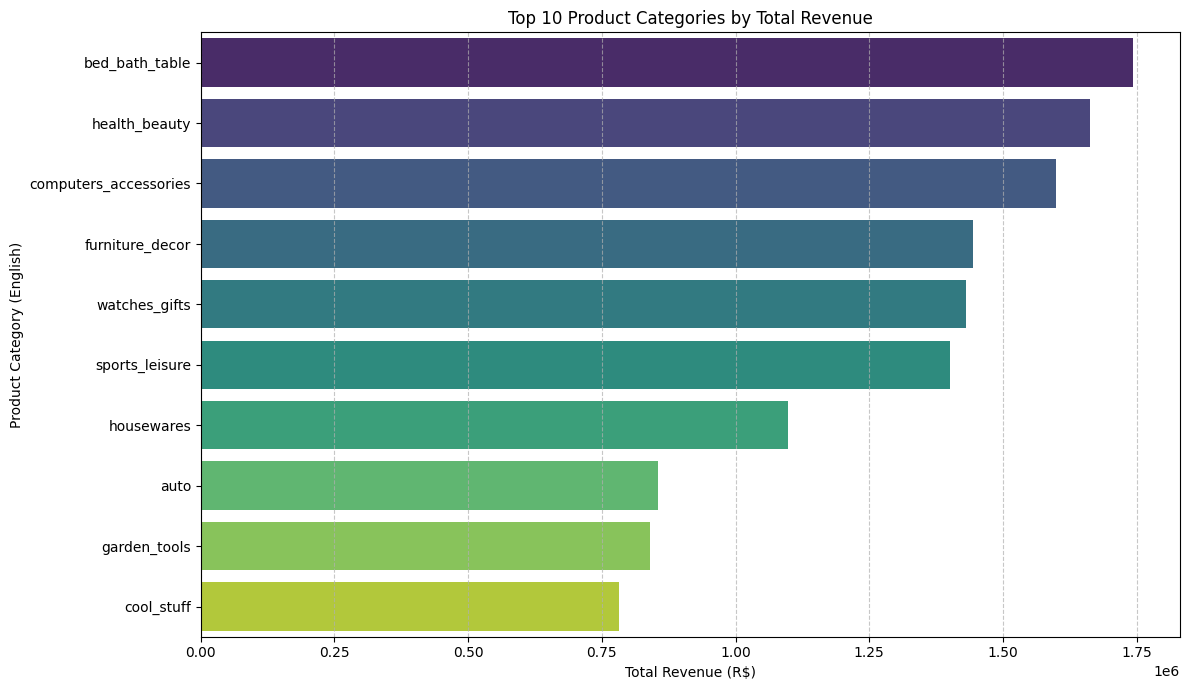

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 categories for visualization
top_10_categories = revenue_by_category.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_categories.values, y=top_10_categories.index, palette='viridis')
plt.title('Top 10 Product Categories by Total Revenue')
plt.xlabel('Total Revenue (R$)')
plt.ylabel('Product Category (English)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Analysis of Cities with the Most Customers

Next, let's identify the cities with the highest number of customers. This can provide insights into the geographical distribution of the customer base.

In [13]:
# Calculate the number of unique customers per city
customers_by_city = main_df.groupby('customer_city')['customer_unique_id'].nunique().sort_values(ascending=False)

print("--- Top 10 Cities by Number of Unique Customers ---")
display(customers_by_city.head(10))

--- Top 10 Cities by Number of Unique Customers ---


,customer_unique_id
customer_city,
sao paulo,14984
rio de janeiro,6620
belo horizonte,2672
brasilia,2069
curitiba,1465
campinas,1398
porto alegre,1326
salvador,1209
guarulhos,1153


Visualizing this data will help in understanding customer distribution more clearly.

/tmp/ipykernel_1153/1102802696.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_cities.values, y=top_10_cities.index, palette='crest')


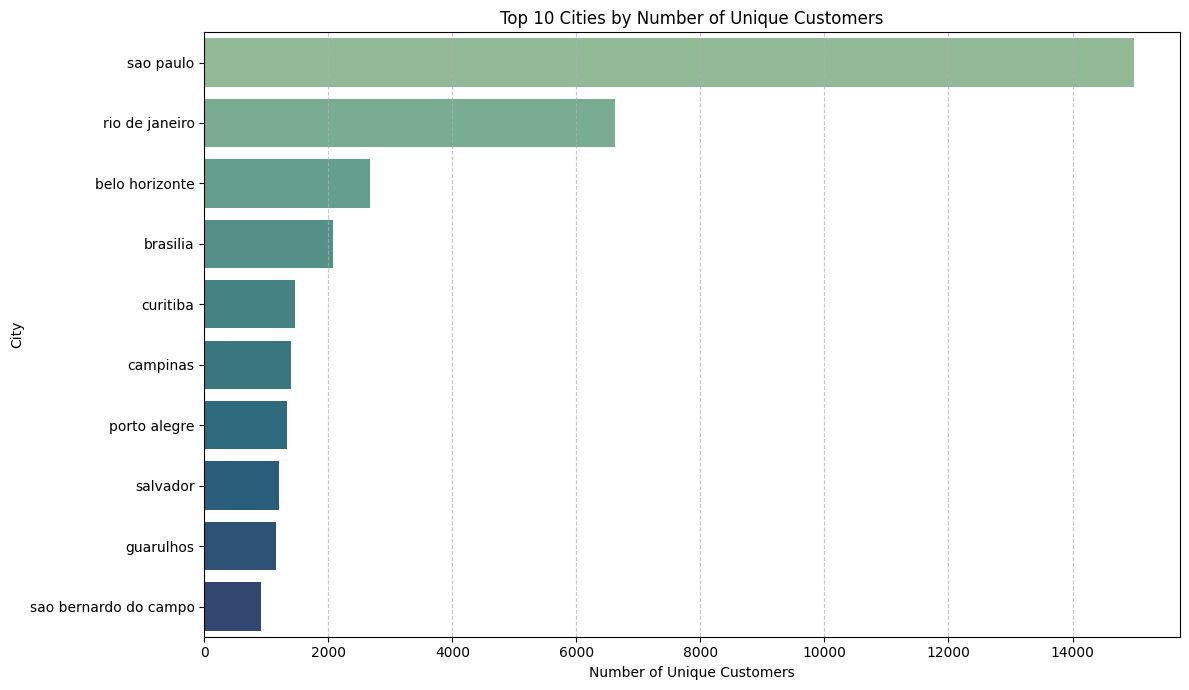

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 cities for visualization
top_10_cities = customers_by_city.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_cities.values, y=top_10_cities.index, palette='crest')
plt.title('Top 10 Cities by Number of Unique Customers')
plt.xlabel('Number of Unique Customers')
plt.ylabel('City')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Analysis of Months with Highest Sales

Next, let's identify the months with the highest sales (`payment_value`) to observe seasonal trends or peak sales periods.

In [15]:
import pandas as pd

# Ensure the column is in datetime format
main_df['order_purchase_timestamp'] = pd.to_datetime(main_df['order_purchase_timestamp'])

# Extract month from order_purchase_timestamp
main_df['order_purchase_month'] = main_df['order_purchase_timestamp'].dt.month

# Calculate total sales per month
sales_by_month = main_df.groupby('order_purchase_month')['payment_value'].sum().sort_values(ascending=False)

print("--- Top Months by Total Sales ---")
display(sales_by_month)

--- Top Months by Total Sales ---


,payment_value
order_purchase_month,
5,2249436.06
8,2133110.99
7,2111509.92
3,2034439.48
4,2012499.64
6,1913460.58
2,1679187.10
1,1616267.67
11,1610581.21


For better visualization, we can display the monthly sales data in a graph.

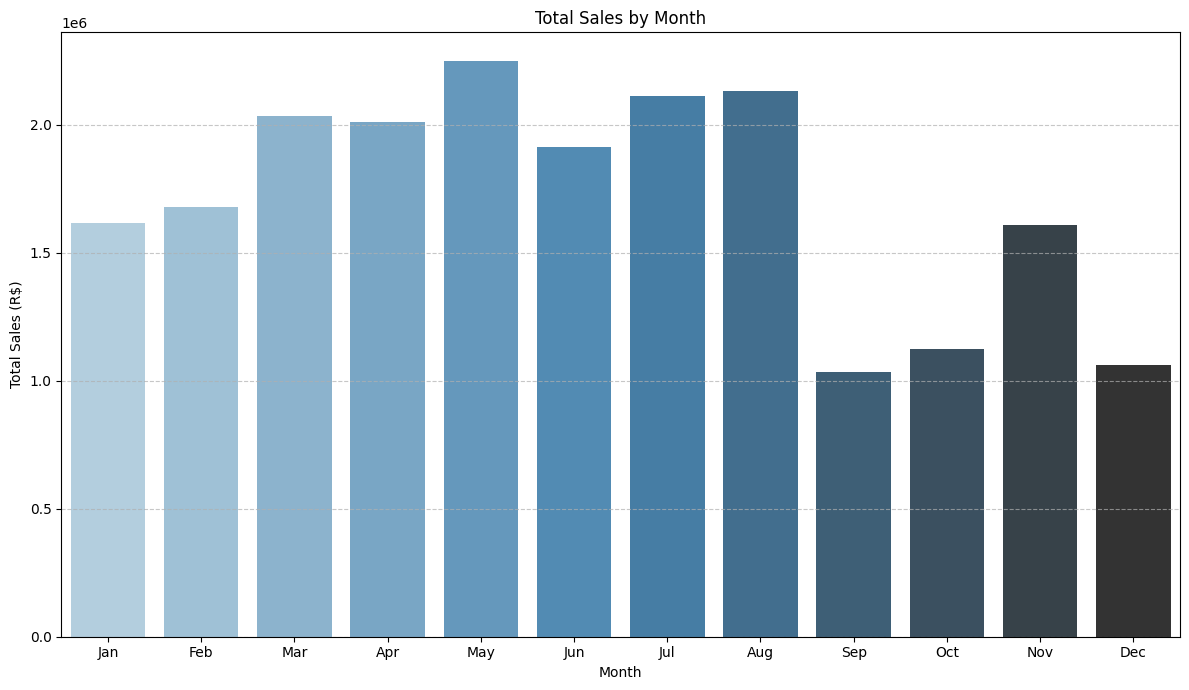

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'order_purchase_timestamp' is datetime type
main_df['order_purchase_timestamp'] = pd.to_datetime(main_df['order_purchase_timestamp'])
# Ensure 'order_purchase_month' is created
main_df['order_purchase_month'] = main_df['order_purchase_timestamp'].dt.month

# Sort months chronologically for line visualization
sales_by_month_sorted = main_df.groupby('order_purchase_month')['payment_value'].sum().sort_index()

plt.figure(figsize=(12, 7))
sns.barplot(x=sales_by_month_sorted.index, y=sales_by_month_sorted.values, palette='Blues_d', hue=sales_by_month_sorted.index, legend=False)
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales (R$)')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Average Order Delivery Time

Now, let's calculate the average time it takes for an order to be delivered to the customer. This can provide insights into logistics efficiency.

In [17]:
import numpy as np
import pandas as pd

# Ensure both columns are in datetime format
main_df['order_delivered_customer_date'] = pd.to_datetime(main_df['order_delivered_customer_date'], errors='coerce')
main_df['order_purchase_timestamp'] = pd.to_datetime(main_df['order_purchase_timestamp'], errors='coerce')

# Calculate delivery duration (difference between delivered date and purchase date)
# Use .dt.days to get the duration in days, ignoring NaT values
main_df['delivery_duration'] = (main_df['order_delivered_customer_date'] - main_df['order_purchase_timestamp']).dt.days

# Calculate the average delivery duration, ignoring NaN values that result from pd.NaT
average_delivery_time_days = main_df['delivery_duration'].mean()

print(f"Average order delivery time: {average_delivery_time_days:.2f} days")

Rata-rata waktu pengiriman pesanan: 12.02 hari


#### Customer Repeat Order Analysis

To understand customer loyalty, let's identify if there are customers who make purchases more than once (repeat orders).

In [18]:
# Calculate the number of unique orders per customer_unique_id
repeat_customers = main_df.groupby('customer_unique_id')['order_id'].nunique()

# Filter customers with more than one order
repeat_customers = repeat_customers[repeat_customers > 1]

print(f"Number of customers making repeat orders: {len(repeat_customers)}")
print("--- Top 10 Customers by Repeat Orders ---")
display(repeat_customers.sort_values(ascending=False).head(10))

Jumlah pelanggan yang melakukan repeat order: 2997
--- 10 Pelanggan dengan Repeat Order Terbanyak ---


,order_id
customer_unique_id,
8d50f5eadf50201ccdcedfb9e2ac8455,17
3e43e6105506432c953e165fb2acf44c,9
6469f99c1f9dfae7733b25662e7f1782,7
ca77025e7201e3b30c44b472ff346268,7
1b6c7548a2a1f9037c1fd3ddfed95f33,7
de34b16117594161a6a89c50b289d35a,6
f0e310a6839dce9de1638e0fe5ab282a,6
dc813062e0fc23409cd255f7f53c7074,6
12f5d6e1cbf93dafd9dcc19095df0b3d,6


#### Further Analysis and Potential Project Ideas

After performing basic analysis, this dataset still holds significant potential for further exploration and predictive model development. Here are some ideas you can expand upon:

1.  **Customer Segmentation**:
    *   **RFM Analysis (Recency, Frequency, Monetary)**: Group customers based on their last purchase (Recency), how often they buy (Frequency), and how much money they spend (Monetary). This can aid in targeted marketing strategies.
    *   **Behavioral Segmentation**: Identify customer groups based on the product categories they purchase, average order value, or other purchasing patterns.

2.  **Seller Performance Analysis**:
    *   **Seller Ranking**: Create a seller ranking system based on sales volume, revenue, review scores, and delivery speed.
    *   **Seller vs. Customer Geolocation**: Analyze the distance between sellers and customers to observe its impact on delivery time and customer satisfaction.

3.  **Advanced Product Analysis**:
    *   **Most Profitable Products**: Beyond total revenue, identify products with the highest profit margins (if cost data is available) or those purchased most frequently.
    *   **Complementary Products/Recommendations**: Find products often bought together to build a recommendation system.
    *   **Product Review Analysis**: Perform sentiment analysis on the `review_comment_message` column to gain deeper insights into customer feedback about products.

4.  **Delivery Time and Logistics Analysis**:
    *   **Factors Influencing Delivery Time**: Identify variables that most affect `delivery_duration` (e.g., distance, seller/buyer location, product category, shipping method).
    *   **Route Optimization**: If more detailed route data is available, it can be used for logistics optimization.

5.  **Predictive Models**:
    *   **Sales Prediction**: Build models to forecast future sales based on historical trends and other factors.
    *   **Order Cancellation Prediction**: Identify factors that lead to order cancellations.
    *   **Review Score Prediction**: Predict review scores based on product, seller, and delivery attributes.

6.  **Richer Data Visualizations**:
    *   **Heatmaps**: Visualize the geographical distribution of sales, customers, or sellers using latitude and longitude.
    *   **Interactive Charts**: Use libraries like Plotly or Bokeh to create visualizations that allow users to explore data in more depth.

Let's start with **RFM analysis** for customer segmentation.

In [19]:
# --- ADVANCED ANALYSIS: RFM SEGMENTATION ---
import datetime as dt

# 1. Define a snapshot date (e.g., one day after the last order in the dataset)
snapshot_date = main_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

# 2. Calculate Recency, Frequency, and Monetary values
rfm = main_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency (days since last purchase)
    'order_id': 'nunique',                                               # Frequency (number of unique orders)
    'payment_value': 'sum'                                                # Monetary (total spend)
})

# 3. Rename columns for clarity
rfm.rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'payment_value': 'Monetary'
}, inplace=True)

# 4. Create scores (1-5) using quantiles
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]) # Higher score for lower recency
# Note: Since most customers have Frequency = 1 (based on repeat order analysis),
# we might need custom bins or focus more on R and M for Frequency scoring.
# For now, let's create a simplified Frequency score.
# A simple approach for Frequency can be based on actual counts or custom bins.
# For this example, let's adjust frequency scoring slightly if many are 1.
# If most are 1, qcut might give same scores to many. Let's use rank for Frequency if needed or custom bins.
# For now, let's proceed with simple qcut, but be aware of its limitations for skewed data.
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]) # Higher score for higher frequency
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]) # Higher score for higher monetary value

# Convert scores to int type
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Combine scores to create an RFM segment string
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# 5. Example of simplified segmentation based on Recency, Frequency, and Monetary scores
def segment_customer(df):
    if df['R_Score'] >= 4 and df['F_Score'] >= 4 and df['M_Score'] >= 4:
        return 'Champions (Loyal, Frequent & Big Spenders)'
    elif df['R_Score'] >= 4 and df['F_Score'] >= 4 and df['M_Score'] < 4:
        return 'Loyal Customers (Frequent & Recent)'
    elif df['R_Score'] <= 2 and df['M_Score'] >= 4:
        return 'At Risk (Big Spenders, but haven\'t purchased lately)'
    elif df['R_Score'] >= 4 and df['M_Score'] <= 2:
        return 'New Customers'
    elif df['F_Score'] >= 4 and df['M_Score'] >= 4:
        return 'Big Spenders (Frequent & High Value)'
    else:
        return 'General / Other'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print("--- RFM Customer Segmentation Counts ---")
print(rfm['Segment'].value_counts())

Segment
General / At Risk                                              50150
Champions (Loyal & Big Spenders)                               15856
Can't Lose Them (Big Spenders who haven't purchased lately)    15084
New Customers                                                  15006
Name: count, dtype: int64
